In [5]:
from google.colab import drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np

# Your file path ends in .xlsx
file_path = '/content/drive/MyDrive/Thesis_BanglaBERT/BengaliTenseCorpus.xlsx'

try:
    print(f"Loading dataset from: {file_path}")

    # CHANGED HERE: Changed pd.read_csv to pd.read_excel
    df = pd.read_excel(file_path)

    print("✓ Dataset loaded successfully!\n")

    # Display basic information
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    print(f"Columns present in dataset: {df.columns.tolist()}")

except FileNotFoundError:
    print("❌ Error: File not found. Please double-check your Google Drive path and file name.")
except Exception as e:
    print(f"❌ An error occurred: {str(e)}")

Loading dataset from: /content/drive/MyDrive/Thesis_BanglaBERT/BengaliTenseCorpus.xlsx
✓ Dataset loaded successfully!

Total Rows: 13500
Total Columns: 3
Columns present in dataset: ['Sentence', 'Tense', 'Sentence (English Translation)']


In [8]:
# 1. Preview the first 5 rows
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# 2. Check for missing (Null) values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 3. Check class distribution
# FIXED HERE: Changed 'label' to 'Tense' to match your dataset
target_column = 'Tense'

if target_column in df.columns:
    print(f"\n--- Class Distribution for '{target_column}' ---")
    print(df[target_column].value_counts())
else:
    print(f"\n⚠️ Warning: '{target_column}' column not found. Check the column list in Cell 2 and update target_column.")

--- First 5 Rows of the Dataset ---


,Sentence,Tense,Sentence (English Translation)
0,দারিদ্র্য একটি অসম্মানজনক নয় তবে এটি ভয়ানক অ...,Present,Poverty is not a disgrace but it is terribly i...
1,ছোট একটি অভিমান হয়ত একদিন বড় কোনো দূরত্বের স...,Present,A small grudge may one day create a big distance
2,স্মৃতির ভাইয়ের সাথে আমি যেন বস্তুত জড়িয়ে আছি,Present,It's like I'm actually connected with Smriti's...
3,পরিবারের অভাবে আমি একা একা পথ চলছি অভিযানে অসহ...,Present,"For lack of family, I travel alone, helpless a..."
4,পড়ালেখা এবং কাজ নিয়ে খুব ব্যস্ত সময় পার করছ...,Present,"I have been very busy with studies and work, b..."



--- Missing Values Check ---
Sentence                          0
Tense                             0
Sentence (English Translation)    0
dtype: int64

--- Class Distribution for 'Tense' ---
Tense
Present    4550
Future     4490
Past       4460
Name: count, dtype: int64


In [9]:
# This downloads/installs the libraries. Takes ~1-2 minutes. You only need to run this once per Colab session.
!pip install -q transformers datasets accelerate scikit-learn
!pip install -q git+https://github.com/csebuetnlp/normalizer

print("✓ Libraries installed")

  Preparing metadata (setup.py) ... done
✓ Libraries installed


In [10]:
import torch

if torch.cuda.is_available():
    print(f"✓ GPU is connected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Go to Runtime → Change runtime type → select a GPU, then rerun from the top.")

✓ GPU is connected: Tesla T4


In [11]:
from normalizer import normalize

TEXT_COL = "Sentence"
LABEL_COL = "Tense"

# Clean/standardize every Bengali sentence (this can take a minute for 13,500 rows)
df[TEXT_COL] = df[TEXT_COL].astype(str).apply(normalize)

# Convert Present/Past/Future text labels into numbers the model can learn from
tense_to_id = {"Present": 0, "Past": 1, "Future": 2}
id_to_tense = {number: tense_name for tense_name, number in tense_to_id.items()}
class_names = [id_to_tense[i] for i in range(len(id_to_tense))]

df["label_id"] = df[LABEL_COL].map(tense_to_id)

print("Label mapping (remember this for later):")
for tense_name, number in tense_to_id.items():
    print(f"  {tense_name} -> {number}")

df[[TEXT_COL, LABEL_COL, "label_id"]].head()

Label mapping (remember this for later):
  Present -> 0
  Past -> 1
  Future -> 2


,Sentence,Tense,label_id
0,দারিদ্র্য একটি অসম্মানজনক নয় তবে এটি ভয়ানক অ...,Present,0
1,ছোট একটি অভিমান হয়ত একদিন বড় কোনো দূরত্বের স...,Present,0
2,স্মৃতির ভাইয়ের সাথে আমি যেন বস্তুত জড়িয়ে আছি,Present,0
3,পরিবারের অভাবে আমি একা একা পথ চলছি অভিযানে অসহ...,Present,0
4,পড়ালেখা এবং কাজ নিয়ে খুব ব্যস্ত সময় পার করছ...,Present,0


In [12]:
from sklearn.model_selection import train_test_split

# First split off 20% for "temp" (which we'll split again into val + test)
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label_id"], random_state=42
)
# Now split that 20% in half -> 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=42
)

print(f"Train rows:      {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows:       {len(test_df)}")

Train rows:      10800
Validation rows: 1350
Test rows:       1350


In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "csebuetnlp/banglabert"
NUM_LABELS = df["label_id"].nunique()  # should be 3: Present, Past, Future

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

print(f"✓ Loaded {MODEL_NAME} with a classification head for {NUM_LABELS} classes")

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Loaded csebuetnlp/banglabert with a classification head for 3 classes


In [14]:
from datasets import Dataset

def to_hf_dataset(pandas_df):
    small = pandas_df[[TEXT_COL, "label_id"]].rename(columns={TEXT_COL: "text", "label_id": "label"})
    return Dataset.from_pandas(small, preserve_index=False)

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=keep_cols)
val_ds.set_format(type="torch", columns=keep_cols)
test_ds.set_format(type="torch", columns=keep_cols)

print("✓ Tokenization complete")
print(train_ds)

Map:   0%|          | 0/10800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

✓ Tokenization complete
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10800
})


In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="/content/banglabert_tense",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="/content/logs",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("✓ Trainer is configured and ready")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Trainer is configured and ready


In [17]:
import sys
# Work around a broken torchvision video backend in some Colab images: the
# `datasets` library opportunistically checks for torchvision when building
# torch tensors, and a broken import there crashes training even though this
# notebook never uses images/video. Unloading it makes datasets skip that check.
sys.modules.pop("torchvision", None)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.030608,0.029610,0.994074,0.994063,0.994096,0.994050
2,0.028560,0.022928,0.996296,0.996294,0.996286,0.996307
3,0.016439,0.024310,0.997037,0.997034,0.997030,0.997040
4,0.006554,0.019321,0.997778,0.997774,0.997778,0.997773
5,0.006201,0.022806,0.997037,0.997034,0.997030,0.997040


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3375, training_loss=0.04133177912124881, metrics={'train_runtime': 1205.0146, 'train_samples_per_second': 44.813, 'train_steps_per_second': 2.801, 'total_flos': 3552031139328000.0, 'train_loss': 0.04133177912124881, 'epoch': 5.0})

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

     Present       1.00      0.99      1.00       455
        Past       1.00      1.00      1.00       446
      Future       1.00      1.00      1.00       449

    accuracy                           1.00      1350
   macro avg       1.00      1.00      1.00      1350
weighted avg       1.00      1.00      1.00      1350



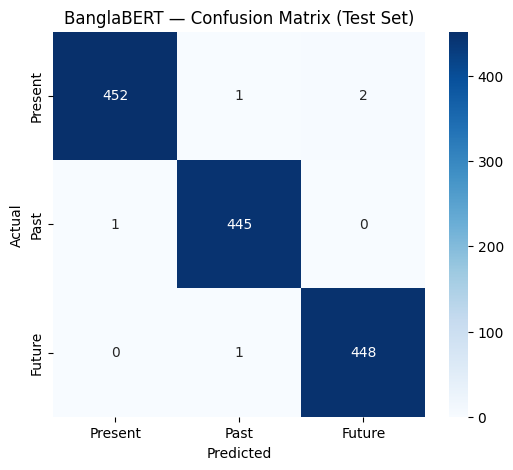

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

predictions_output = trainer.predict(test_ds)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print("--- Classification Report (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BanglaBERT — Confusion Matrix (Test Set)")
plt.show()

In [19]:
SAVE_PATH = "/content/drive/MyDrive/Thesis_BanglaBERT/banglabert_tense_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✓ Model and tokenizer saved to: {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model and tokenizer saved to: /content/drive/MyDrive/Thesis_BanglaBERT/banglabert_tense_model
